In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import zipfile

In [2]:
output_dir = Path("/mnt/data/taller_cv_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

In [3]:

h, w = 512, 512
img = np.full((h, w, 3), 220, dtype=np.uint8)


cv2.rectangle(img, (40, 60), (200, 200), (0, 255, 0), -1)
cv2.circle(img, (360, 140), 70, (0, 0, 255), -1)
pts = np.array([[260,320],[420,360],[320,440]], np.int32)
cv2.fillPoly(img, [pts], (255,0,0))


overlay = img.copy()
cv2.rectangle(overlay, (50,300),(230,480),(0,120,200), -1)
alpha = 0.5
cv2.addWeighted(overlay, alpha, img, 1-alpha, 0, img)


cv2.putText(img, "TEST 3D/IMG", (60, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (50,50,50), 2, cv2.LINE_AA)


orig_path = output_dir/"01_original.png"
cv2.imwrite(str(orig_path), img)


True

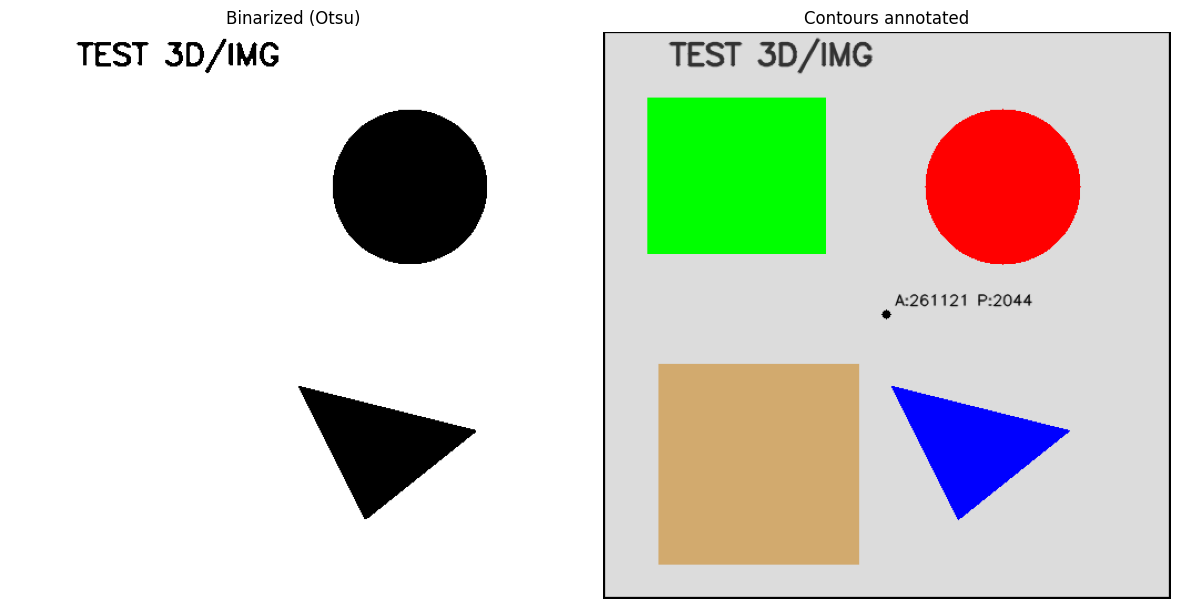

In [4]:
# -------------------------
# ejercicio 6 - Análisis Geométrico
# -------------------------
def exercise_6(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, hierarchy = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    ann = image.copy()
    metrics = []
    for i, c in enumerate(contours):
        area = cv2.contourArea(c)
        peri = cv2.arcLength(c, True)
        M = cv2.moments(c)
        if M['m00'] != 0:
            cx = int(M['m10']/M['m00'])
            cy = int(M['m01']/M['m00'])
        else:
            cx, cy = 0, 0

        cv2.drawContours(ann, [c], -1, (0,0,0), 2)
        cv2.circle(ann, (cx,cy), 4, (0,0,0), -1)

        txt = f"A:{int(area)} P:{int(peri)}"
        cv2.putText(ann, txt, (cx+8, cy-8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,0), 1, cv2.LINE_AA)
        metrics.append({'contour_id': i, 'area': area, 'perimeter': peri, 'centroid': (cx,cy)})
    return th, ann, metrics, contours

th, ann, metrics, contours = exercise_6(img)


fig2, ax2 = plt.subplots(1,2, figsize=(12,6))
ax2[0].imshow(th, cmap='gray'); ax2[0].set_title("Binarized (Otsu)"); ax2[0].axis('off')
ax2[1].imshow(cv2.cvtColor(ann, cv2.COLOR_BGR2RGB)); ax2[1].set_title("Contours annotated"); ax2[1].axis('off')
plt.tight_layout()
ex6_path = output_dir/"exercise_6_results.png"
plt.savefig(str(ex6_path), dpi=150)
plt.show()


import pandas as pd
df_metrics = pd.DataFrame(metrics)

csv_path = output_dir/"exercise_6_metrics.csv"
df_metrics.to_csv(str(csv_path), index=False)
